# Decision Tree Classification - Real Dataset Implementation

This notebook demonstrates the implementation of a **Decision Tree Classifier** on the **Loan Prediction Dataset**. The goal is to build a machine learning model that predicts whether a loan application will be approved (`Loan_Status`) based on applicant demographics and financial history.

### 1. Library Imports
We import standard data handling (`numpy`, `pandas`), plotting (`matplotlib`, `seaborn`), and machine learning tools (`scikit-learn`) for training and evaluating our Decision Tree classifier.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 2. Loading the Dataset
We load the Loan Prediction dataset from the `Datasets` folder using `pd.read_csv()`.

In [13]:
dataset = "../../Datasets/loan_prediction.csv"

df = pd.read_csv(dataset)

df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


### 3. Inspecting the First and Last Rows
We display the first and last five rows of our dataset to understand its structure, features, and alignment.

In [14]:
print(df.head())
print()
print(df.tail())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

### 4. Dimensions of the Dataset
We check the shape of the dataset to see the total number of records (loan applications) and columns (features + target).

In [15]:
df.shape

(614, 13)

### 5. Column Metadata and Data Types
We call `.info()` to check for the list of columns, data types, and check the count of non-null values.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


### 6. Checking for Missing (Null) Values
We compute the sum of null values for each column to determine the necessary imputation strategy.

In [17]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### 7. Checking for Duplicate Records
We inspect if there are any identical duplicate rows that could bias our model's performance.

In [18]:
df.duplicated().sum()

np.int64(0)

### 8. Summary Statistics
We run `.describe(include='all')` to view summary descriptive statistics of the features. This helps us understand the distribution, ranges, and basic summary metrics of both numerical and categorical features.

In [19]:
df.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


### 9. Exploratory Data Analysis (EDA) - Visualizations
We generate several visualizations to explore the features and their relationships with the target variable:
1. **Target Variable (`Loan_Status`)**: To check for class balance/imbalance.
2. **Categorical Features vs. Target**: Visualizing how features like `Credit_History`, `Education`, `Married`, and `Property_Area` affect loan approval.
3. **Numerical Features vs. Target**: Analyzing the distributions of `ApplicantIncome`, `CoapplicantIncome`, and `LoanAmount` using boxplots.
4. **Correlation Heatmap**: Reviewing pairwise correlations among numerical columns.

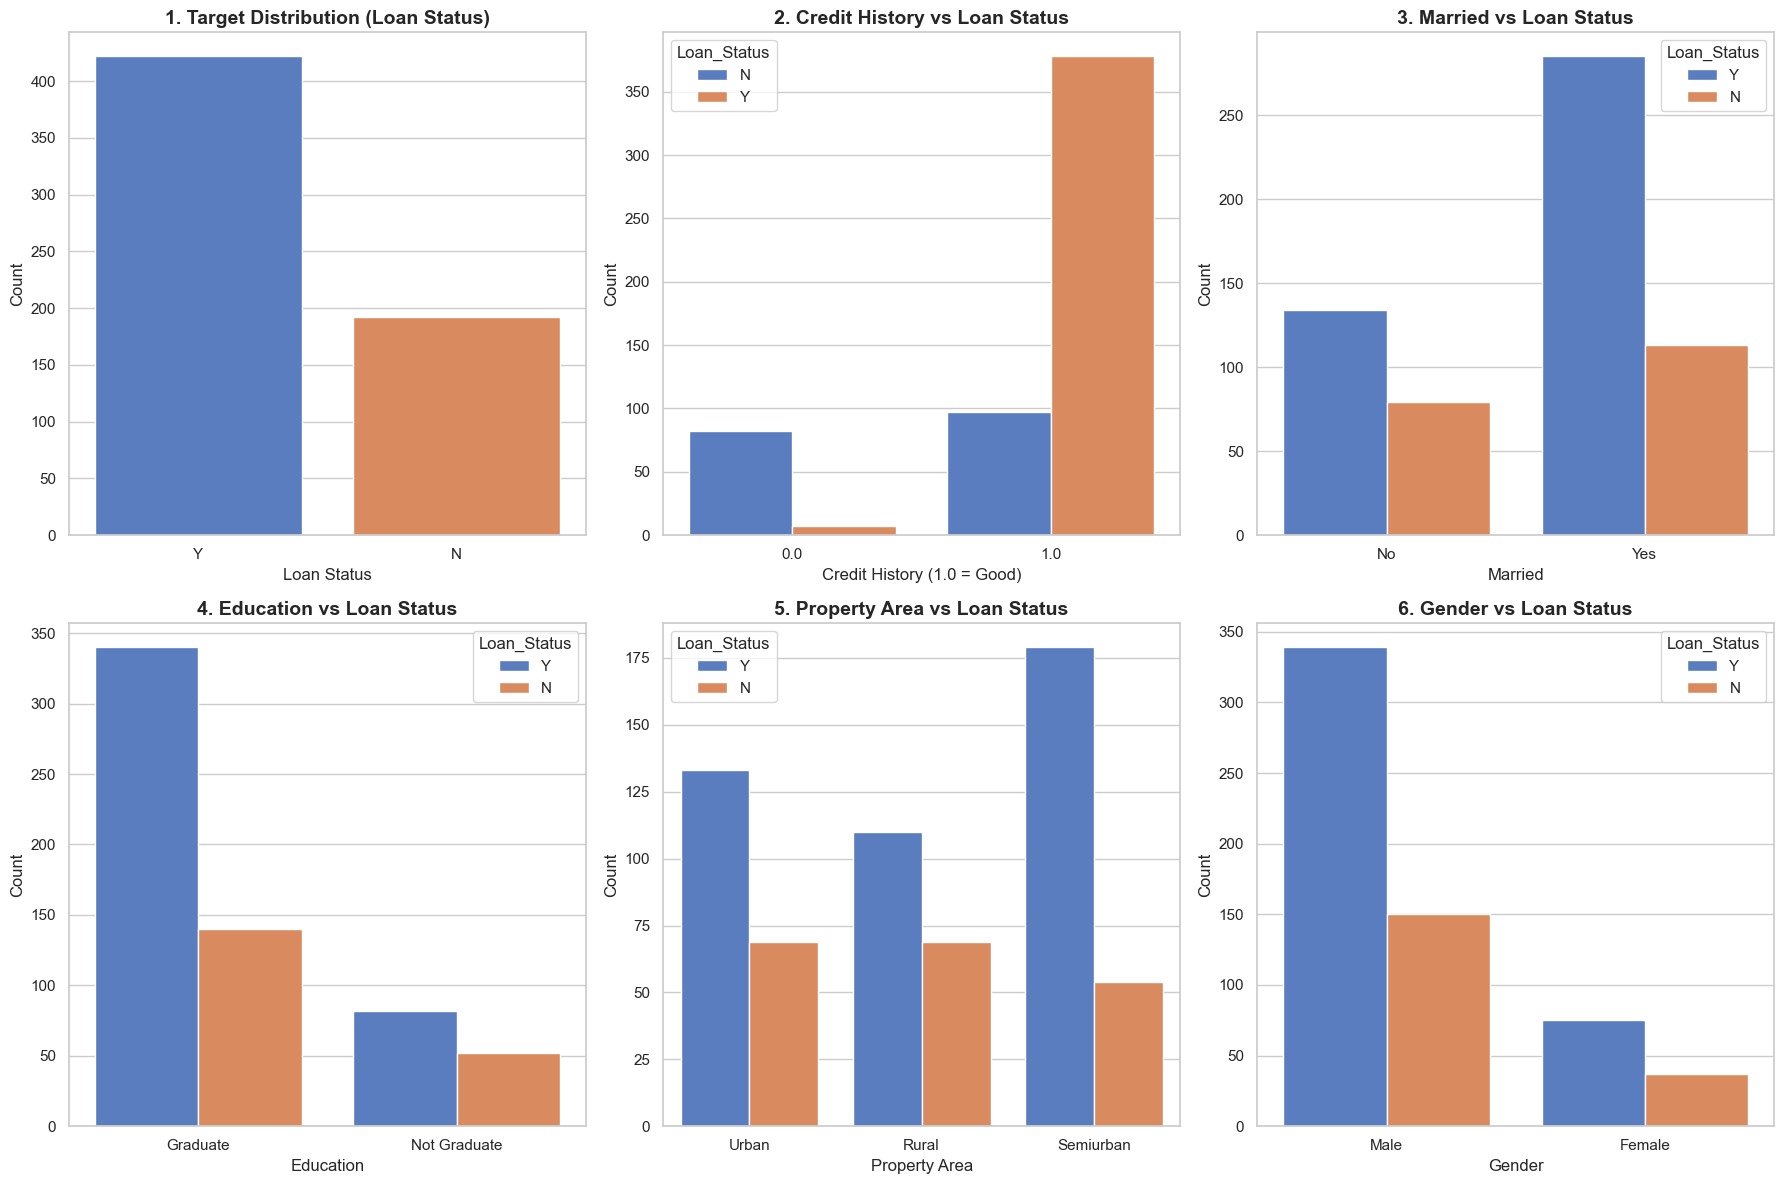

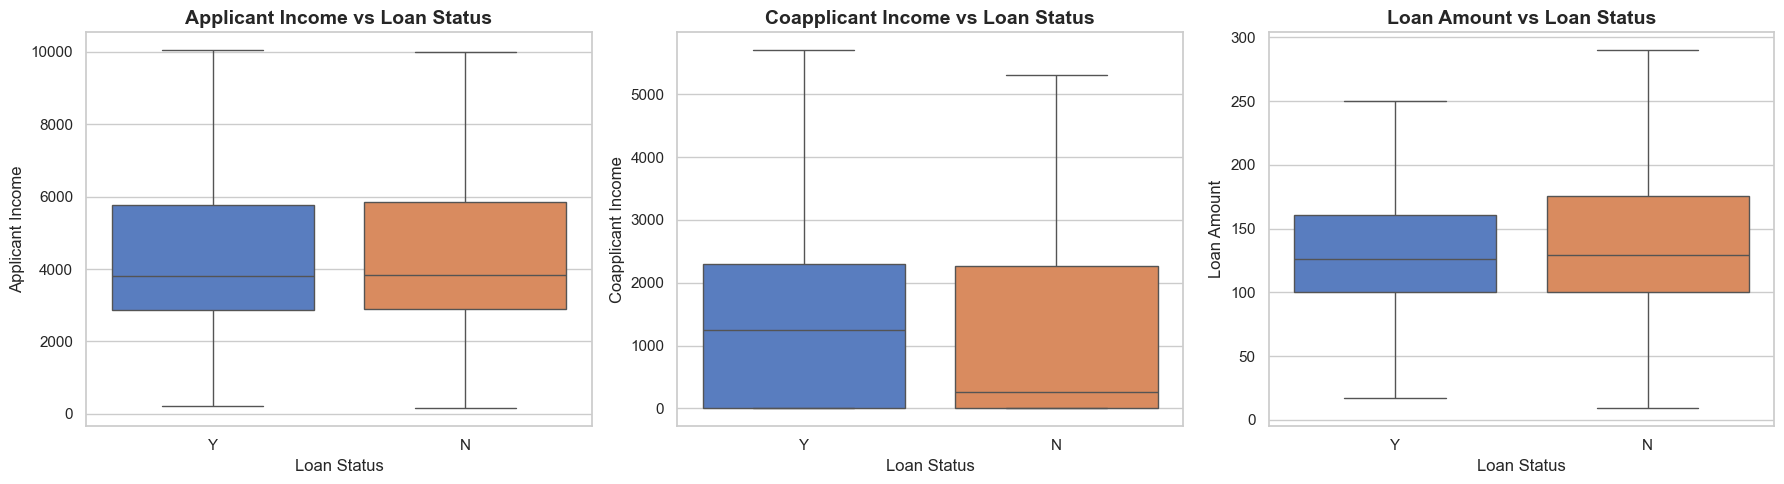

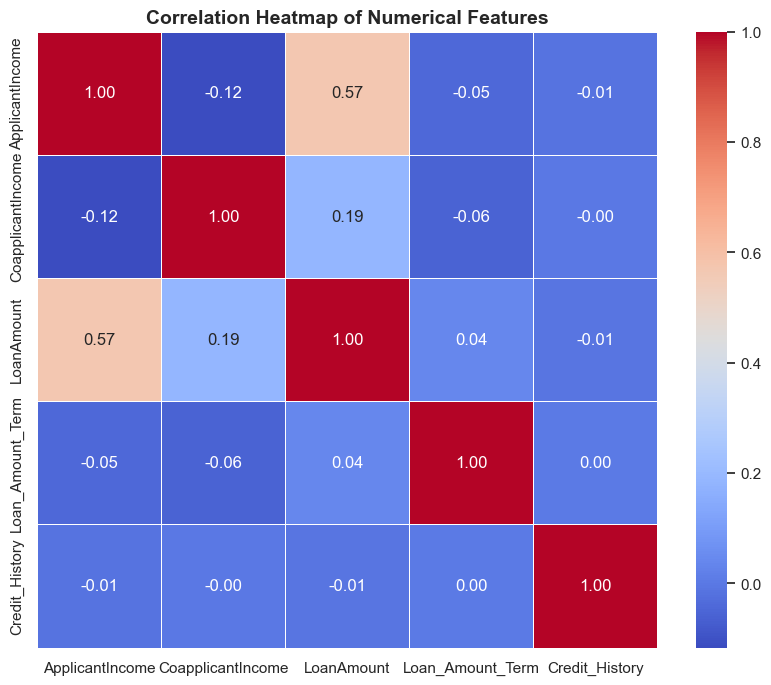

In [20]:
# Set up plotting style
sns.set_theme(style="whitegrid", palette="muted")

# 1. Target Distribution & Categorical Feature Relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Target Variable Distribution
sns.countplot(x='Loan_Status', data=df, ax=axes[0, 0], hue='Loan_Status', legend=False)
axes[0, 0].set_title('1. Target Distribution (Loan Status)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Loan Status', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)

# Credit History vs Loan Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, ax=axes[0, 1])
axes[0, 1].set_title('2. Credit History vs Loan Status', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Credit History (1.0 = Good)', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)

# Married vs Loan Status
sns.countplot(x='Married', hue='Loan_Status', data=df, ax=axes[0, 2])
axes[0, 2].set_title('3. Married vs Loan Status', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Married', fontsize=12)
axes[0, 2].set_ylabel('Count', fontsize=12)

# Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df, ax=axes[1, 0])
axes[1, 0].set_title('4. Education vs Loan Status', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Education', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)

# Property Area vs Loan Status
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, ax=axes[1, 1])
axes[1, 1].set_title('5. Property Area vs Loan Status', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Property Area', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)

# Gender vs Loan Status
sns.countplot(x='Gender', hue='Loan_Status', data=df, ax=axes[1, 2])
axes[1, 2].set_title('6. Gender vs Loan Status', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Gender', fontsize=12)
axes[1, 2].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

# 2. Numerical Distributions by Loan Status
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=axes[0], showfliers=False, hue='Loan_Status', legend=False)
axes[0].set_title('Applicant Income vs Loan Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Status', fontsize=12)
axes[0].set_ylabel('Applicant Income', fontsize=12)

sns.boxplot(x='Loan_Status', y='CoapplicantIncome', data=df, ax=axes[1], showfliers=False, hue='Loan_Status', legend=False)
axes[1].set_title('Coapplicant Income vs Loan Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loan Status', fontsize=12)
axes[1].set_ylabel('Coapplicant Income', fontsize=12)

sns.boxplot(x='Loan_Status', y='LoanAmount', data=df, ax=axes[2], showfliers=False, hue='Loan_Status', legend=False)
axes[2].set_title('Loan Amount vs Loan Status', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Loan Status', fontsize=12)
axes[2].set_ylabel('Loan Amount', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Correlation Heatmap (of numerical features)
# Keep only numerical columns for correlation calculation
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

### 10. Handling Missing Values
We identify columns with missing data and impute them using appropriate strategies:
- For categorical features (`Gender`, `Married`, `Dependents`, `Self_Employed`, `Credit_History`), we fill missing values with their **mode**.
- For numerical features (`LoanAmount`, `Loan_Amount_Term`), we fill missing values with their **median**.

In [24]:
columns = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]

for col_mode in columns :
    df[col_mode] = df[col_mode].fillna(df[col_mode].mode()[0])

cols = ["LoanAmount", "Loan_Amount_Term"]

for col_median in cols :
    df[col_median] = df[col_median].fillna(df[col_median].median())

### 11. Cleaning the 'Dependents' Feature
We clean the `Dependents` column by removing the `+` sign from values like `3+`, converting it into an integer representation to ensure it is suitable for model training.

In [30]:
df['Dependents'] = df['Dependents'].astype(str).str.replace('+', '', regex=False).astype(int)

### 12. Encoding Categorical Variables
We use `LabelEncoder` to convert categorical variables (such as `Gender`, `Married`, `Education`, `Self_Employed`, `Loan_Status`, and `Property_Area`) into numerical values so they can be processed by the machine learning algorithm.

In [31]:
encoder = LabelEncoder()

encode_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status', 'Property_Area']

for col in encode_cols:
    df[col] = encoder.fit_transform(df[col])

### 13. Feature Engineering
We create new domain-specific features to capture relationships between different variables:
- `TotalIncome`: Combined income of applicant and co-applicant.
- `LoanToIncomeRatio`: Ratio of the loan amount to total income.
- `IncomePerDependent`: Income split among family members.

In [27]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

df["LoanToIncomeRatio"] = df["LoanAmount"] / df["TotalIncome"]

df["IncomePerDependent"] = df["TotalIncome"] / (df["Dependents"] + 1)

### 14. Splitting Independent (X) and Dependent (y) Variables
We separate the target variable (`Loan_Status`) from the independent features ($X$), dropping the unique identifier `Loan_ID` as it does not contribute to the model.

In [34]:
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

### 15. Train-Test Split
We partition the dataset into an 80% training set (to fit the decision tree model) and a 20% test set (to evaluate its performance), using `random_state=42` to ensure reproducible results.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 16. Training the Decision Tree Classifier
We fit a `DecisionTreeClassifier` with `max_depth=4` and `max_leaf_nodes=6` to balance complexity and interpretability, training it on the preprocessed training dataset.

In [46]:
tree_model = DecisionTreeClassifier(max_depth=4, max_leaf_nodes=6, random_state=42)

tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",6
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node,

### 17. Generating Predictions
We generate predictions on the test set using our trained decision tree model.

In [47]:
y_pred_tree = tree_model.predict(X_test)

y_pred_tree

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

### 18. Model Evaluation
We evaluate the performance of our model on the test set using metrics such as Accuracy, a Classification Report (precision, recall, F1-score), and a Confusion Matrix.

In [48]:
accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.8130081300813008

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.56      0.68        43
           1       0.80      0.95      0.87        80

    accuracy                           0.81       123
   macro avg       0.83      0.75      0.77       123
weighted avg       0.82      0.81      0.80       123


Confusion Matrix:
[[24 19]
 [ 4 76]]


### 19. Visualizing the Decision Tree
We plot the structure of the trained Decision Tree model to interpret the decision rules and feature thresholds used to classify loan applications.

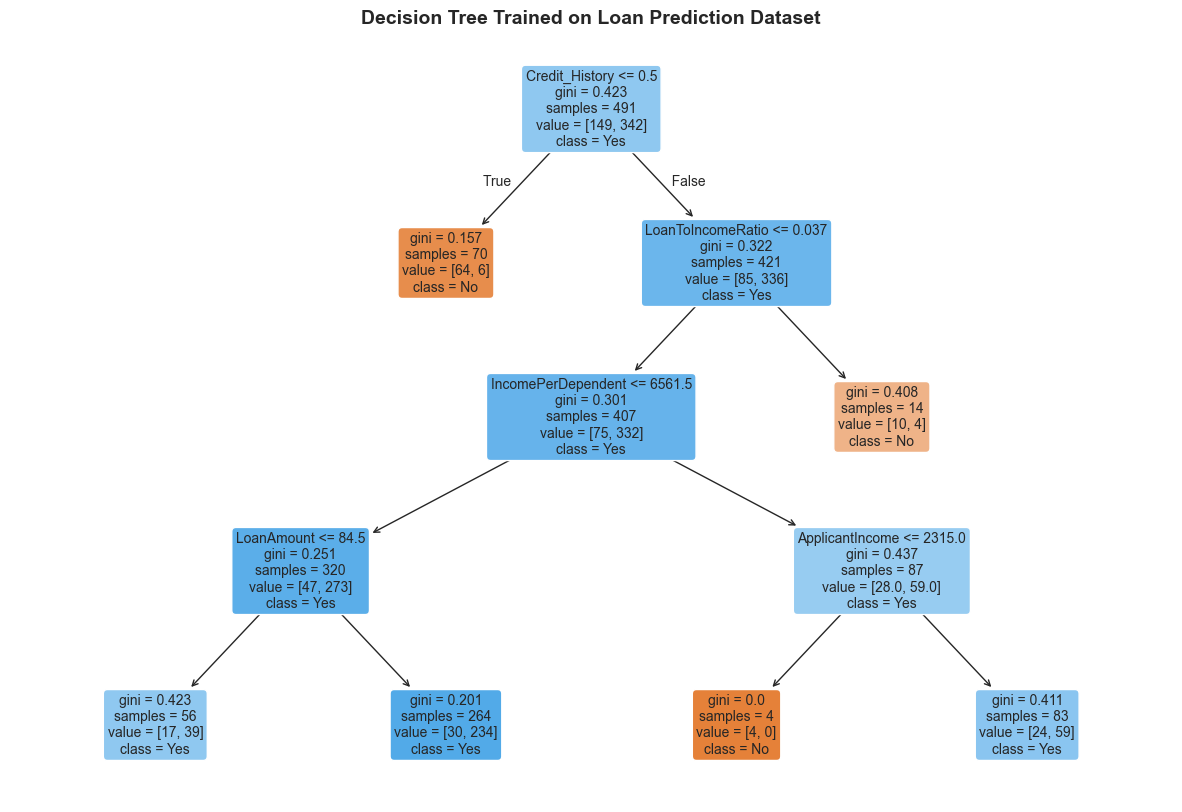

In [49]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(tree_model, 
          feature_names=list(X.columns), 
          class_names=['No', 'Yes'], 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Trained on Loan Prediction Dataset", fontsize=14, fontweight='bold')
plt.show()

### 20. Summary and Key Findings

This notebook demonstrated the implementation of a Decision Tree classifier with limited depth to predict loan approval status based on applicant details.

### Data Analysis Key Findings
* **Model Classification Performance**: The model achieved an overall accuracy of **81.30%** on the test set. It performed particularly well on predicting positive classes (recall of **95.00%** and F1-score of **0.87** for class 1).
* **Confusion Matrix Details**:
  * **True Negatives**: 24 loan applications correctly predicted as not approved.
  * **True Positives**: 76 loan applications correctly predicted as approved.
  * **False Positives**: 19 loan applications predicted as approved but actually rejected.
  * **False Negatives**: 4 loan applications predicted as rejected but actually approved.

### Insights or Next Steps
* **Mitigate False Positives**: The model has a relatively high rate of False Positives (19 out of 43 actual negative cases). This indicates a tendency to approve risky loans. Tuning the class weight or threshold could help.
* **Compare with Ensemble Models**: As a single decision tree can be unstable and prone to high variance, we should evaluate a Random Forest model next to see if we can reduce false positives and improve overall classification quality.